# 5.3 Nonlinear Boundary Value Problem

In [9]:
using NonlinearSolve
using CairoMakie

So far, we have only looked at linear boundary value problem. In many real situations, the equations are nonlinear.  Consider radiation heat transfer from a cylindrical plate.  The governing equation for the temperature distribution is given by

$\frac{d^2 T}{dr^2} + \frac{1}{r}\frac{d T}{dr} = d(T^4 - T_R^4) - g(r)$

You are given that $r\in[0,5]$, $d=0.1$, $T_R=10$ and $g(r)=(r-5)^2$.

Again you use the finite diference approximation

$\frac{d^2T}{dr^2}\approx\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta^2}$ 

$\frac{dT}{dr}\approx\frac{T_{i+1}-T_{i-1}}{2\Delta}$ 

We substitute back into the original equation to get

$\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta^2}+\frac{1}{r_i}\frac{T_{i+1}-T_{i-1}}{2\Delta}=d(T_i^4 - T_R^4) - g(r_i)$

This equation is nonlinear (due to the $T^4$ term, we cannot put it into matrix form).  For a grid with 6 data points, we have

$(T_2-T_1)/\Delta=0 \rightarrow T_2-T_1=0$

$\frac{T_{1}-2T_2+T_{3}}{\Delta^2}+\frac{1}{r_2}\frac{T_{3}-T_{1}}{2\Delta}=d(T_2^4 - T_R^4) - g(r_2)$

$\frac{T_{2}-2T_3+T_{4}}{\Delta^2}+\frac{1}{r_3}\frac{T_{3}-T_{2}}{2\Delta}=d(T_3^4 - T_R^4) - g(r_3)$

$\frac{T_{3}-2T_4+T_{5}}{\Delta^2}+\frac{1}{r_4}\frac{T_{3}-T_{3}}{2\Delta}=d(T_4^4 - T_R^4) - g(r_4)$

$\frac{T_{4}-2T_5+T_{6}}{\Delta^2}+\frac{1}{r_5}\frac{T_{3}-T_{4}}{2\Delta}=d(T_5^4 - T_R^4) - g(r_5)$

$T_6=10 \rightarrow T_6-10=0$

In [10]:
d=0.1;TR=10;R=5;
Delta=0.01;
r=0:Delta:R;

Set up parameters of the problem

In [11]:
N=length(r); #n is the number gridpoints
T=zeros(N);
p=[R,d,TR,Delta]


HeatedDiskExample(T,p)

501-element Vector{Float64}:
    0.0
 1024.9001
 1024.8004
 1024.7009
 1024.6016
 1024.5025
 1024.4036
 1024.3049
 1024.2064
 1024.1081
    ⋮
 1000.0064
 1000.0049
 1000.0036
 1000.0025
 1000.0016
 1000.0009
 1000.0004
 1000.0001
  -10.0

Define the nonlinear vector functions

In [12]:
function HeatedDiskExample(T,p)
    R=p[1]
    d=p[2]
    TR=p[3]
    Delta=p[4]

    func=vcat( T[1]-T[2],
        ((T[3:N]-2*T[2:N-1]+T[1:N-2])/Delta^2.0).+(1/(2*Delta*r[2:N-1]))*(T[3:N].-T[1:N-2]).-d*(T[2:N-1].^4.0.-TR^4).+(r[2:N-1].-R).^2,
       T[N]-TR)

    return func
end   

HeatedDiskExample (generic function with 1 method)

In [13]:
HeatedDiskExample(T,p)

501-element Vector{Float64}:
    0.0
 1024.9001
 1024.8004
 1024.7009
 1024.6016
 1024.5025
 1024.4036
 1024.3049
 1024.2064
 1024.1081
    ⋮
 1000.0064
 1000.0049
 1000.0036
 1000.0025
 1000.0016
 1000.0009
 1000.0004
 1000.0001
  -10.0

Use Julia code to solve the problem.

In [14]:
x0=ones(length(r)) #initial guess
prob = NonlinearProblem(HeatedDiskExample,x0,p)
sol = NonlinearSolve.solve(prob)

retcode: Stalled
u: 501-element Vector{Float64}:
 10.060584421628123
 10.060584421628123
 10.060540149668556
 10.060459772501256
 10.060349966331993
 10.060216188838313
 10.060062901561686
 10.059893751720901
 10.059711720846776
 10.059519246290241
  ⋮
 10.000020999201615
 10.000016968836906
 10.000013376485747
 10.000010208453439
 10.00000744801824
 10.00000507476245
 10.000003063755662
 10.000001384557502
 10.0

Plot the solution

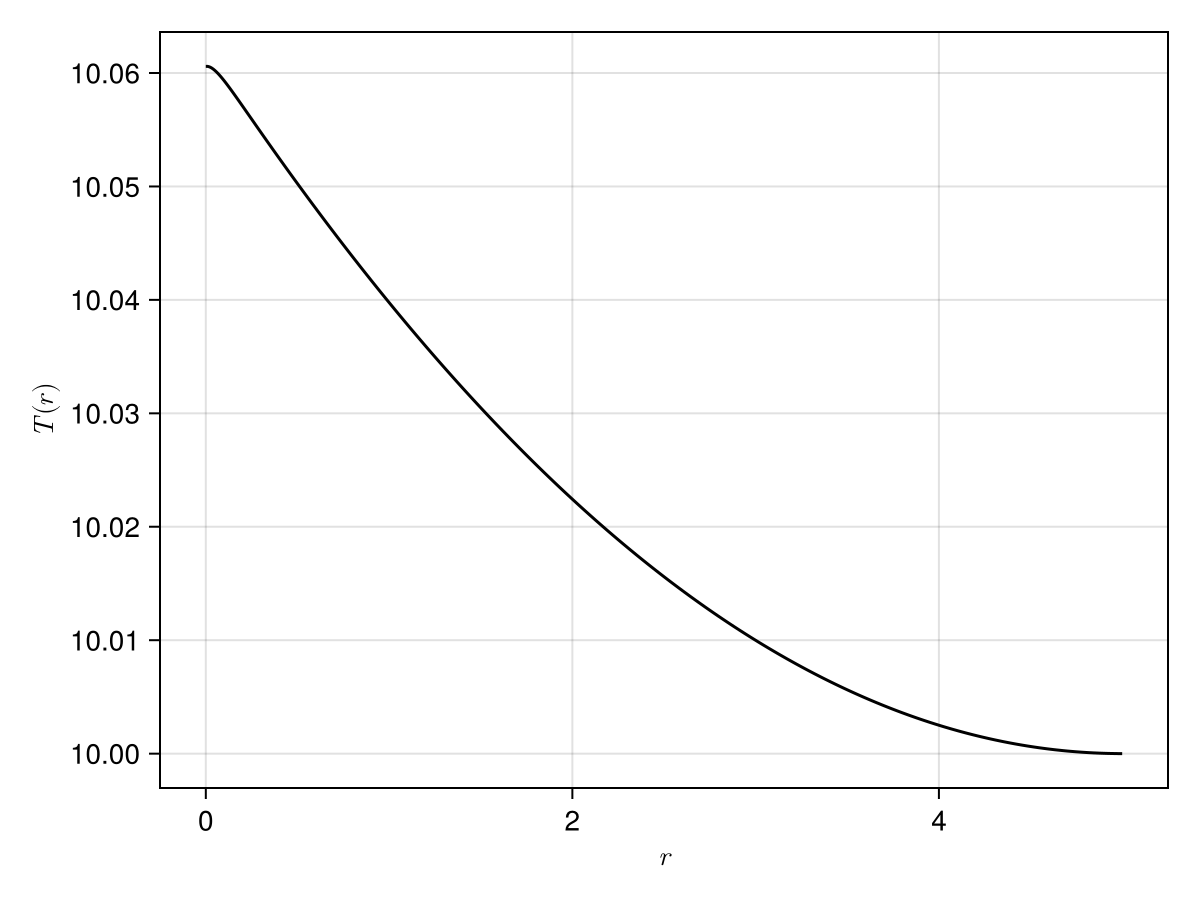

CairoMakie.Screen{IMAGE}


In [15]:
fig = Figure() #set up a figure
ax1 = Axis(fig[1, 1], xlabel = L"r", ylabel = L"T(r)") #Define axis in the figure
lines!(ax1,r,sol.u;color=:black) #Plot i_5 vs V_1
display(fig)